## `TP Deep Clustering` 

L'objectif de ce TP consiste à créer un modèle constitué de plusieurs parties :

- Un auto-codeur, pré-entraîné pour apprendre la représentation condensée initiale des jeux de données non étiquetés.
- Une couche de clustering empilée sur l'encodeur pour affecter la sortie de l'encodeur à un cluster. Les poids de la couche de clustering sont initialisés avec les centres de cluster de K-Means basés sur l'évaluation actuelle.
- Entraîner le modèle de clustering pour affiner la couche de clustering et le codeur conjointement.


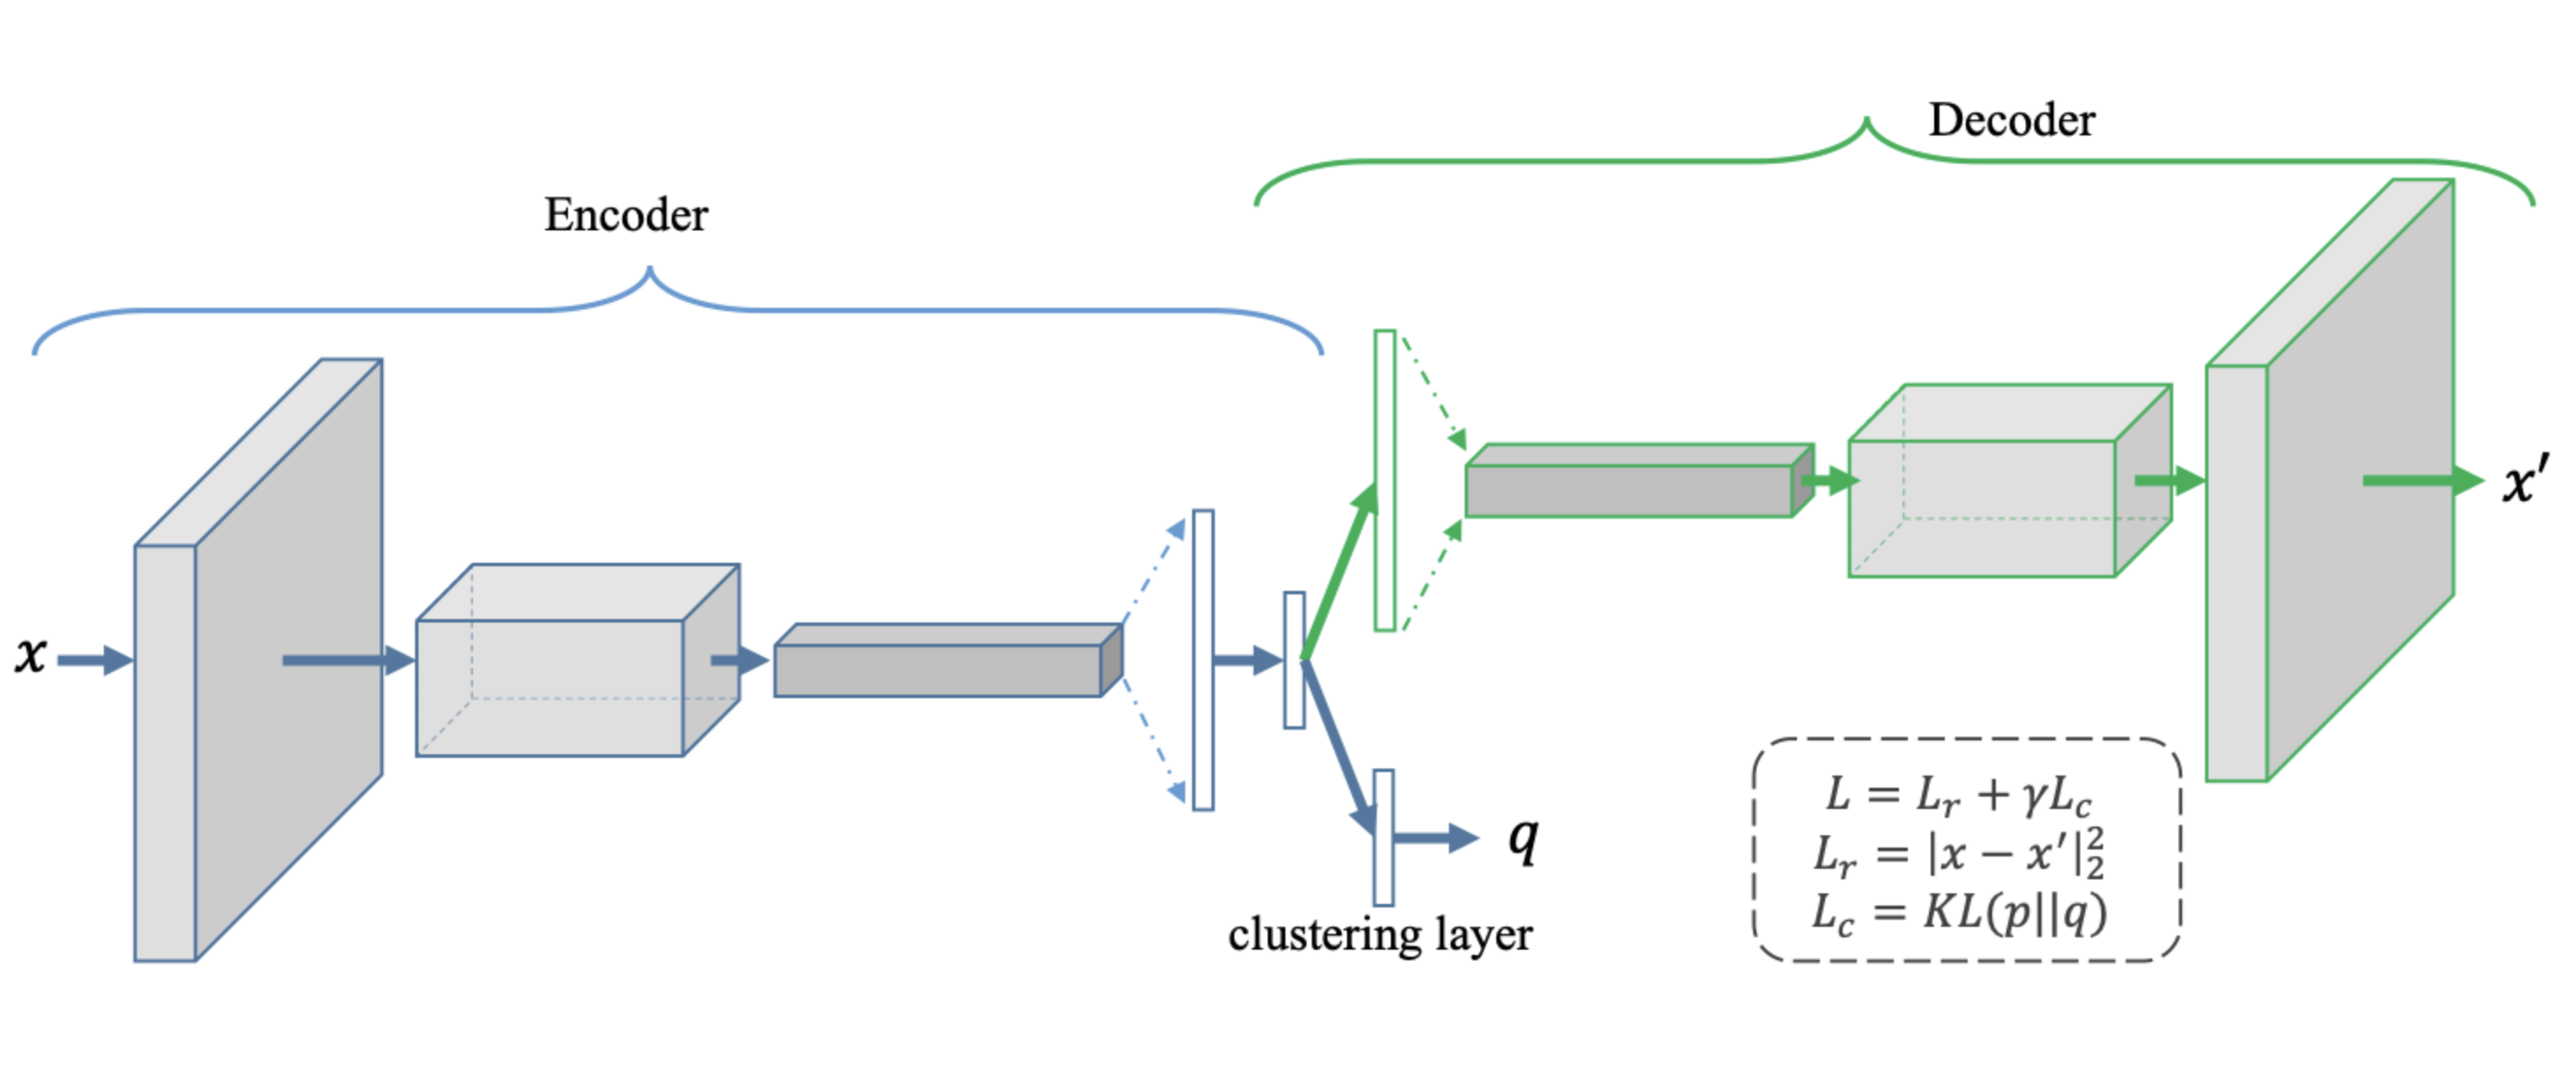

In [1]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/DeepClustering.png",width=700))

`L’encoder + k‑means en non supervisé :`
 - Pipeline non supervisé encoder + k‑means
 - Pré‑entraînement non supervisé de l’encoder

`Autoencoder conv :` 
 - apprend à reconstruire l’image, donc l’espace latent z se structure sans labels.
 - Ou méthode type DEC / Deep Embedded K‑Means où l’encoder est entraîné avec une loss qui dépend des clusters eux‑mêmes (distribution cible, KL, etc.).

`Clustering dans l'espace latent`
 - on passe les images dans l’encoder, 
 - récupères les embeddings $z_i$, 
 - on appliques k‑means sur les ${z_i}$.

`Les indices de clusters de k‑means sont tes pseudo‑labels non supervisés`.
- Option raffinement (deep embedded clustering)
 - On ré‑entraînes l’encoder en forçant les embeddings à se rapprocher des centres de leurs clusters (loss basée sur la KL entre assignations et une distribution cible plus « piquée »).

Les seules « étiquettes » sont produites par k‑means à partir des features apprises, pas par un annotateur humain.

In [111]:
from time import time
import numpy as np
import keras.backend as K # type: ignore
from tensorflow.keras.layers import Layer, InputSpec, UpSampling2D, Flatten, Reshape, Conv2DTranspose  # type: ignore
from tensorflow.keras.models import Model  # type: ignore
from tensorflow.keras.initializers import VarianceScaling  # type: ignore
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

### `Chargement des données`

In [149]:
from keras.datasets import mnist  # type: ignore
from keras.datasets import fashion_mnist  # type: ignore à tester, + complexe que l'ensemble mnist 

import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST/Fashion mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train.shape : {x_train.shape}")
x_trainIm = x_train.astype('float32') / 255.
x_testIm = x_test.astype('float32') / 255.

print(f"x_trainIm.shape : {x_trainIm.shape}")
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))

print(f"x_train_rshp.shape : {x_train_rshp.shape}")

x_train.shape : (60000, 28, 28)
x_trainIm.shape : (60000, 28, 28)
x_train_rshp.shape : (60000, 784)


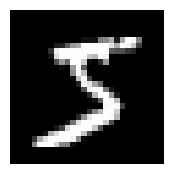

In [150]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()

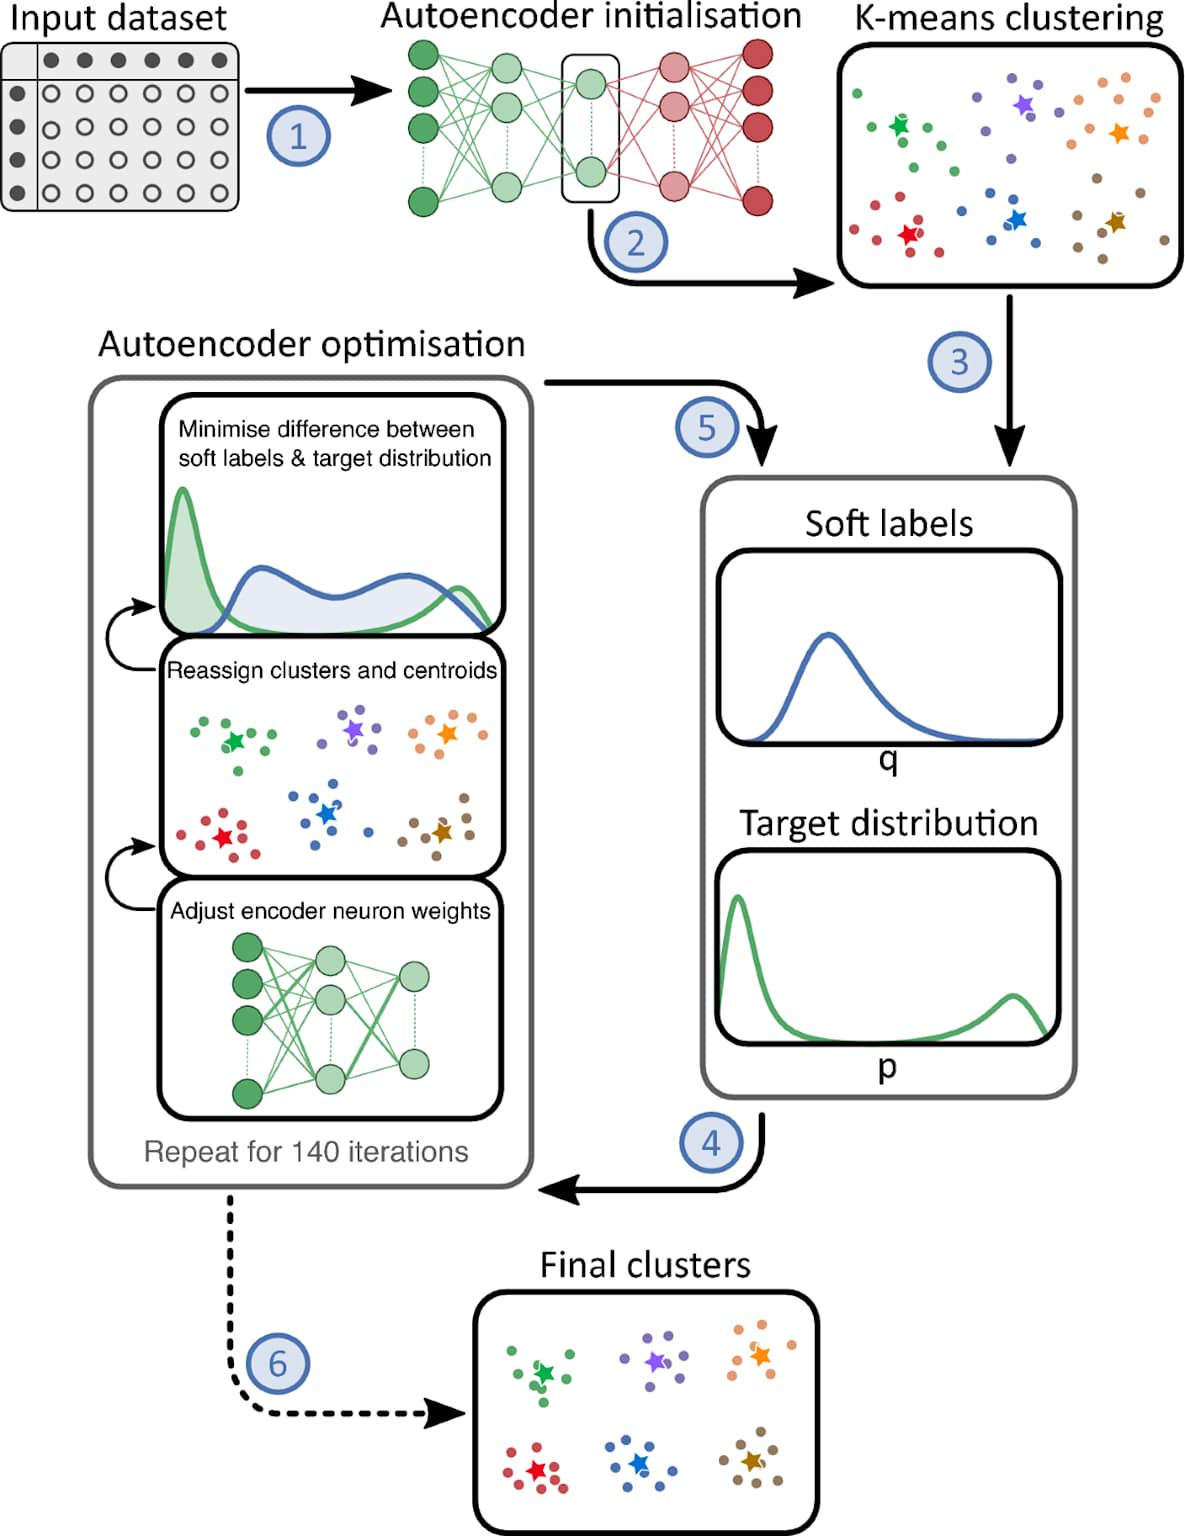

In [126]:
from IPython.display import Image, display
display(Image("M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/otoncdrKmnsClstrg.jpg",width=400))

### `Baseline par clustering classique par kmeans`

`y_pred_kmeans` 
- vecteur d’entiers de taille (n_samples,) 
- contient l’indice du cluster auquel KMeans a affecté chaque sample (0, 1, ..., n_clusters-1)
- il n’y a pas de correspondance directe entre indice de cluster et indice de classe. 
- les indices de KMeans sont arbitraires

In [151]:
# Nombre de classes à trouver
n_clusters=10
# nombre de chiffres
n_digits = len(np.unique(y_test))
print(f"n_digits : {n_digits}")
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
print(f"y_pred_kmeans.shape : {y_pred_kmeans.shape}")
print(f"y_pred_kmeans : {y_pred_kmeans}")

n_digits : 10
y_pred_kmeans.shape : (60000,)
y_pred_kmeans : [2 5 9 ... 2 4 6]


`Ecrire acc = accuracy_score(y_pred_kmeans, y_train) n’a pas de sens.`

Les options cohérentes sont donc :
 - remapping cluster → classe (via matrice de confusion + Hungarian) puis calculer l’accuracy;
 - utiliser des métriques de clustering (Adjusted Rand Index, NMI, etc.) plutôt qu’une accuracy.

In [128]:
# Score de performance
acc = accuracy_score(y_pred_kmeans, y_train)
print(f"Accuracy KMeans (fit_predict) : {acc:.4f}")

Accuracy KMeans (fit_predict) : 0.1269


### `Attribution des étiquettes de cluster`

 - La classification K-means est une méthode d'apprentissage automatique non supervisée
 - Les étiquettes KMeans référence la classification attribué à chaque élément et non à l'entier cible réel
 - Les fonctions ci-dessous permettent de prédir à quel classe correspond à chaque cluster

__`Ce que signifie cet appel`__
 - y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans.
 - y_train sont les vraies étiquettes (supervisées) de tes données d’entraînement.
 - `retrieve_info(cluster_labels, y_train)`
   - calcule, pour chaque cluster, la classe majoritaire dans ce cluster 
   - renvoie un tableau reference_labels qui fait la correspondance
   - reference_labels[i] = classe majoritaire parmi les points du cluster i.

In [171]:
def retrieve_info(cluster_labels, y_train):
    cluster_labels = np.asarray(cluster_labels).ravel()
    y_train = np.asarray(y_train).ravel()
    n_clusters = len(np.unique(cluster_labels))
    reference_labels = np.zeros(n_clusters, dtype=int)   # <-- 1D
    #print(f"cluster_labels : {cluster_labels.shape}")
    for i in range(n_clusters):
        index = (cluster_labels == i)
        num = np.bincount(y_train[index]).argmax()
        reference_labels[i] = num
    #print(f"index.shape : {index.shape}")    
    return reference_labels


- `La fonction correspondance effectue le mapping numéro de cluster classe réel`
- `Pour chaque prédiction cluster associé à un élement, la classe correspondante`

In [153]:
def correspondance(y_pred_kmeans,y_train):
  # y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans, 
  # reference_labels[i] = classe majoritaire parmi les points du cluster i.
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels

`Obtenir un score de performance`
- Après la correspondance clusters → classes, 
- Utiliser _reference_labels_ pour transformer les labels de clusters en labels de classes, 
- puis calculer une accuracy classique.

In [154]:
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
print(f"y_train_pred.shape : {y_train_pred.shape}")

# score de performance sur l'apprentissage
score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy KMeans (apprentissage) : {score:.4f}")

cluster_labels : (60000,)
index.shape : (60000,)
y_train_pred.shape : (60000,)
Accuracy KMeans (apprentissage) : 0.4859


In [155]:
# Affichage des données 
count=60000
ListeData = np.random.choice(len(y_train_pred), count)
inputs = x_train_rshp[ListeData]
classes = y_train[ListeData]
embedTSNE = TSNE(n_components=2).fit_transform(inputs)

In [156]:
import matplotlib.pyplot as plt

def display_2Dreduce(classes,embedTSNE=[] ,embedPCA=[], mode=("TSNE", "PCA")):
    """
    mode peut contenir :
      - ("TSNE", "PCA")  -> les deux graphiques côte à côte
      - ("TSNE",)        -> uniquement t-SNE
      - ("PCA",)         -> uniquement PCA
    """
    color = classes.astype(int)

    show_tsne = "TSNE" in mode
    show_pca  = "PCA" in mode

    if show_tsne and show_pca:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax = axes[0]
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        fig.colorbar(sc, ax=ax)

        ax = axes[1]
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        fig.colorbar(sc, ax=ax)

        plt.tight_layout()
        plt.show()

    elif show_tsne:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        plt.colorbar(sc)
        plt.show()

    elif show_pca:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        plt.colorbar(sc)
        plt.show()


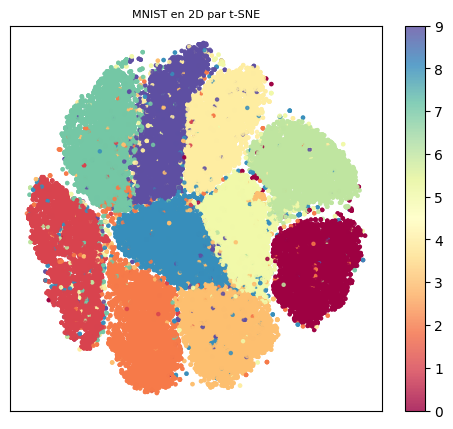

In [157]:
display_2Dreduce(classes,embedTSNE=embedTSNE, mode=("TSNE"))

### `Autoencodeur classique à définir`

In [158]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input #type: ignore

# Autoencodeur simple pour MNIST (28x28 -> 784)
autoencoder = Sequential([
    Input(shape=(784,)),          # image 28x28 aplatie
    Dense(128, activation="relu"),
    Dense(64, activation="relu"), # couche "bottleneck"
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid")  # reconstruction 784, même taille que l'entrée
])

In [159]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   
    metrics=["accuracy"],
)

### `Entraînement de l'autoencodeur` 

In [160]:
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train_rshp, x_train_rshp,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_rshp, x_test_rshp))

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.0086 - loss: 0.0687 - val_accuracy: 0.0110 - val_loss: 0.0193
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0106 - loss: 0.0173 - val_accuracy: 0.0111 - val_loss: 0.0124
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0106 - loss: 0.0122 - val_accuracy: 0.0102 - val_loss: 0.0101
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0119 - loss: 0.0100 - val_accuracy: 0.0140 - val_loss: 0.0089
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0134 - loss: 0.0087 - val_accuracy: 0.0139 - val_loss: 0.0078
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0134 - loss: 0.0078 - val_accuracy: 0.0133 - val_loss: 0.0071
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0145 - loss: 0.0073 - val_accuracy: 0.0139 - val_loss: 0.0066
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.0136 - loss: 0.0068 - val_accu

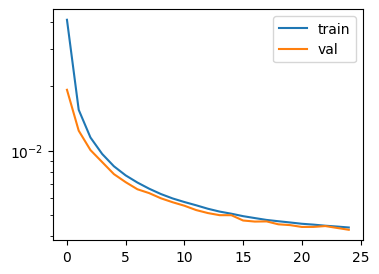

In [161]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.yscale("log")

In [162]:
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,578 (2.50 MB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,386 (1.66 MB)

In [163]:
# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train_rshp[:1]) 

# 2) Récupérer l'input via la première couche
inp = Input(shape=(784,))
x = autoencoder.layers[0](inp)  # Dense(128)
code = autoencoder.layers[1](x)  # Dense(64)
encoder = Model(inp, code)

# decoder : code latent -> reconstruction
latent_input = Input(shape=(64,))
x = autoencoder.layers[2](latent_input)   # Dense(128)
decoded_output = autoencoder.layers[3](x) # Dense(784)
decoder = Model(latent_input, decoded_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


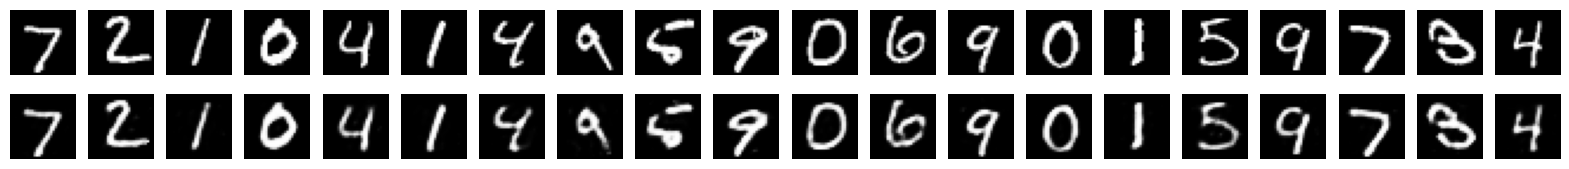

In [164]:
n = 20  # Combien de chiffres nous allons afficher
# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# encoder / decoder
encoded_imgs = encoder.predict(x_test_rshp[:n])
decoded_imgs = decoder.predict(encoded_imgs)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_rshp[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
encoded_imgs.shape : (60000, 64)


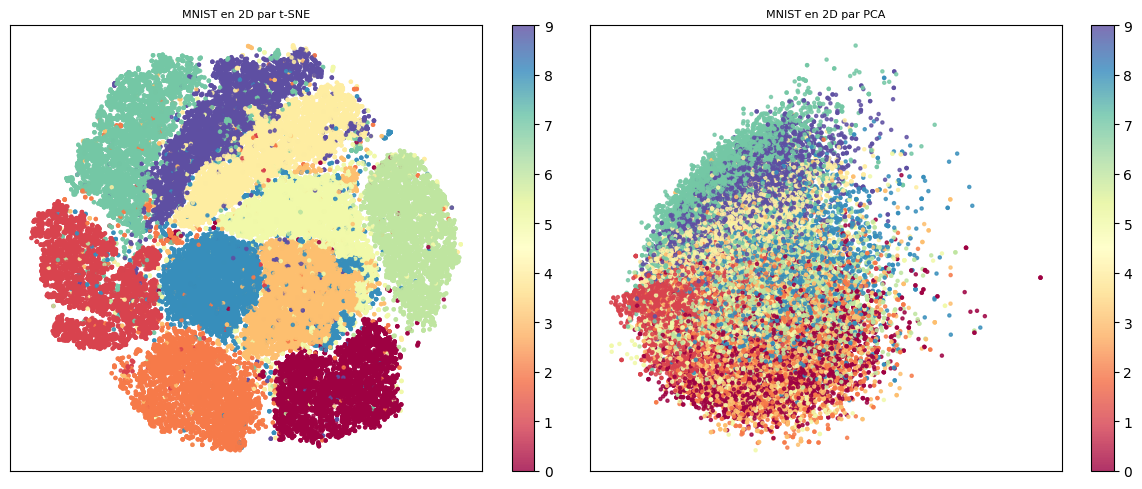

In [169]:
# Affichage de l'espace latent par réduction de dimension 
count=2000
inputs = x_train[ListeData]
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
classes = y_train[ListeData]
# Récupération des données dans l'espace latent
encoded_imgs = encoder.predict(x_train_rshp)
print(f"encoded_imgs.shape : {encoded_imgs.shape}")
# 1) Réduction de dimension 2D par ACP et affichage
embedPCA = PCA(n_components=2).fit_transform(encoded_imgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_imgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(classes,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : 0.5467


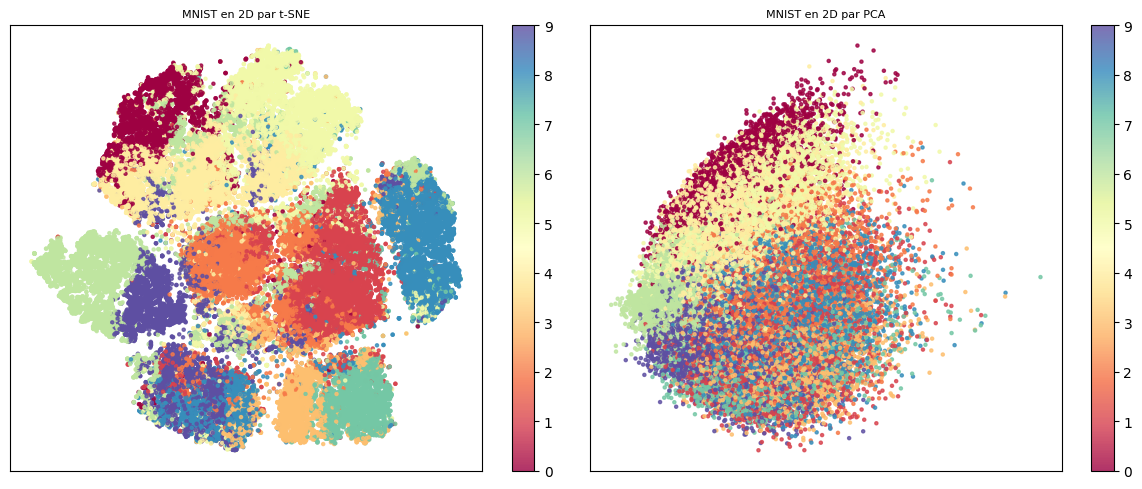

In [172]:
# Classification par kmeans de l'espace latent sur l'ensemble d'apprentissage
inputsTrain = x_train.astype('float32') / 255
inputsTrain_rshp = np.reshape(inputsTrain, (len(inputsTrain), 784))
classesTrain = y_train
# Récupération des données dans l'espace latent
encoded_allimgs = encoder.predict(inputsTrain_rshp)
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)
# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(inputsTrain_rshp)
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
# Score de performance sur l'apprentissage
acc = accuracy_score(y_train_pred, classesTrain)
print(f"Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : {acc:.4f}")
# 2) Réduction de dimension 2D avec PCA
embedPCA = PCA(n_components=2).fit_transform(encoded_allimgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_allimgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(y_pred_kmeans,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

### `Couche de Clustering` 
:::
`Deep Embedded Clustering (DEC)` 
 - C'est une couche de Clustering
 - Elle prend un vecteur de caractéristiques (la sortie de l'encodeur) 
 - Le transforme en probabilités d’appartenance aux clusters via une `distribution t de Student`.
 - La couche de clustering maintient les centres de cluster $µ_j$ comme poids entraînables 
 - Elle projette chaque point intégré $z_i$ en soft label $q_i$ par la distribution $t$ de Student 
 - Elle est utilisée comme noyau pour mesurer la similarité entre $zi = fθ(x_i)$ et le centroïd $µ_j$ :

$$q_{ij}=\frac{(1+\|z_i-\mu_j\|^2)^{-1}}{\sum_j(1+\|z_i-\mu_j\|^2)^{-1}}$$

 - $q_{ij}$ est la $j^{ième}$ entrée de $q_i$, représentant la probabilité d'appartenance de $z_i$ au cluster $j$
 :::
 :::
 `La « t de Student »` 
  - Est une distribution de probabilité (Student’s t), 
  - Utilisée comme noyau pour mesurer la similarité entre un point latent $x_i$ et un centroïde $u_j$,
  - Exactement comme dans t‑SNE et DEC.
 $$q_{ij} \propto \left( 1 + \frac{\lVert x_i - u_j \rVert^{2}}{\alpha} \right)^{-\frac{\alpha + 1}{2}}$$
 - Puis on normalise sur $j$ pour obtenir une distribution de probabilité sur les clusters (soft labels)
:::
:::
`Pourquoi faire`
Contrairement à KMeans classique (hard labels), on obtient des assignations molles (soft assignments).
Comme cette couche est différentiable et intégrée au réseau, on peut apprendre conjointement :
- la représentation latente (l’encodeur), 
- les centres de clusters (self.clusters),
- en minimisant par exemple une KL entre cette distribution $q$ et une distribution cible p (c’est DEC).
:::
:::
`KL, c’est la divergence de Kullback–Leibler (souvent notée $D_{KL}$)` 
$$D_{\text{KL}}(P \parallel Q)= \sum_{x \in X} P(x)\,\log \frac{P(x)}{Q(x)}$$
 - Cette mesure quantifie à quel point une distribution de probabilité $Q$ est différente d’une distribution « vraie » $P$
 - Imaginons que $P$ est la « vraie » loi des données et $Q$ une approximation (modèle).
 - $D_{KL}(P||Q)$ mesure combien d’information on perd, en moyenne, si on encode les données 
 - comme si elles suivaient $Q$ alors qu’elles suivent en réalité $P$
 - Si $P = Q$, la divergence est 0 (pas de perte).
 - Plus $Q$ est différent de $P$ plus le KL est grand.


 Avec les autoencodeurs/clustering profonds (comme DEC), on minimise souvent une KL entre une distribution cible P (par ex. labels « affinés ») et la distribution de clusters produite par le modèle Q
:::


In [173]:
class ClusteringLayer(Layer):
    """
    La couche de classification convertit l'échantillon d'entrée (caractéristique) en une étiquette souple,
    c'est-à-dire un vecteur qui représente la probabilité d'appartenance de l'échantillon à chaque groupe.
    probabilité d'appartenance de l'échantillon à chaque cluster. La probabilité est calculée avec la 
    distribution t de student.
    # Exemple
    ```
        model.add(ClusteringLayer(n_clusters=10))
    ```
    # Arguments
        n_clusters : nombre de clusters.
        weights : liste de tableaux Numpy de forme `(n_clusters, n_features)` 
        qui représente les centres de clusters initiaux.
        alpha : paramètre de la distribution t de Student. La valeur par défaut est 1.0.
    # Forme de l'entrée
        Tenseur 2D avec la forme : `(n_samples, n_features)`.
    # Forme en sortie
        Tenseur 2D avec forme : `(n_samples, n_clusters)`.
    """
    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=K.floatx(), shape=(None, input_dim))
        self.clusters = self.add_weight(shape=(self.n_clusters, input_dim), initializer='glorot_uniform', name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    def call(self, inputs, **kwargs):
      """ Distribution t de student, la même que celle utilisée dans l'algorithme t-SNE.
                     q_ij = 1/(1+dist(x_i, u_j)^2), puis normalisation.
        Arguments : inputs : la variable contenant les données, shape=(n_samples, n_features)
        Retourne  : q la distribution t de student, ou des étiquettes souples pour chaque échantillon. shape=(n_samples, n_clusters)
        """
      # distance au carré entre chaque point et chaque centroïde
      q = 1.0 / (1.0 + (K.sum(K.square(K.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
      #  # noyau t de Student
      q **= (self.alpha + 1.0) / 2.0
      # # normalisation par ligne
      q = K.transpose(K.transpose(q) / K.sum(q, axis=1))
      # q a shape (n_samples, n_clusters) et chaque ligne est un vecteur de probabilités qui somme à 1
      return q

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


Définition de la distribution $P$ cible définie comme
$$p_{ij}=\frac{q_{ij}^2/\sum_i q_{ij}}{\sum_j (q_{ij}^2/\sum_i q_{ij})}.$$
où $p_{ij}$ est la $j$ième entrée de $p_i$ représentant la probabilité d'appartenance de la donnée $i$ la classe $j$

Dans DEC, la distribution cible  $P=(p_{ij})$ se calcule à partir de $Q=(q_{ij}) (la sortie de ta ClusteringLayer) en renforçant les assignations confiantes.

La formule standard est :
$$p_{ij}= \frac{\dfrac{q_{ij}^2}{\sum_i q_{ij}}}{\sum_{j} \dfrac{q_{ij}^2}{\sum_i q_{ij} }}$$

In [175]:
# Calcul de la distribution cible
import tensorflow.keras.backend as K # type: ignore

def target_distribution(q):
    # f_j = somme_i q_ij
    f = K.sum(q, axis=0)                       # (n_clusters,)
    weight = (q ** 2) / f                      # (n_samples, n_clusters)
    p = weight / K.sum(weight, axis=1, keepdims=True)
    return p


In [183]:
import numpy as np

def target_distribution(q):
    weight = q ** 2 / q.sum(0)           # (n_samples, n_clusters)
    return (weight.T / weight.sum(1)).T  # normalisation ligne


In [184]:
# Configuration de la couche de clustering
clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
model = Model(inputs=encoder.input, outputs=clustering_layer)

model.compile(optimizer="Adam", loss='kld')

# Entrainement du modèle avec la couche de clustering

In [185]:
# paramètres à fixer
loss = 0
index = 0
maxiter =4000
update_interval = 140
batch_size=128
index_array = np.arange(x_train.shape[0])
tol = 0.005 # seuil pour critère d'arrêt

In [186]:
inputs = x_train
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))

In [ ]:
#Initialisation Kmeans
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
y_pred = kmeans.fit_predict(encoder.predict(x_train_rshp))

# récupération des centres de clusters   
y_pred_last = np.copy(y_pred)
model.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])

for ite in range(int(maxiter)):
    if ite % update_interval == 0:
        q = model.predict(x_train_rshp, verbose=0)
        p = target_distribution(q)  # mise à jour de la distribution cible p 

        # evaluation de la performance du clustering 
        y_pred = q.argmax(1)
        if y_train is not None: 
            y_pred=correspondance(y_pred,y_train)
            acc = np.round(accuracy_score(y_train, y_pred), 5)
            loss = np.round(loss, 5)
            print('(Iter , acc)  ',(ite, acc), ' ; loss=', loss)

        # check stop criterion - model convergence
        delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
        y_pred_last = np.copy(y_pred)
        if ite > 0 and delta_label < tol:
            print('delta_label ', delta_label, '< tol ', tol)
            print('Reached tolerance threshold. Stopping training.')
            break
    idx = index_array[index * batch_size: min((index+1) * batch_size, x_train_rshp.shape[0])]
    loss = model.train_on_batch(x=x_train_rshp[idx], y=p[idx])
    index = index + 1 if (index + 1) * batch_size <= x_train.shape[0] else 0

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
(Iter , acc)   (0, 0.38425)  ; loss= 0
(Iter , acc)   (140, 0.37792)  ; loss= 0.03383
(Iter , acc)   (280, 0.37715)  ; loss= 0.06146
(Iter , acc)   (420, 0.37737)  ; loss= 0.09611
(Iter , acc)   (560, 0.37797)  ; loss= 0.12193
(Iter , acc)   (700, 0.37645)  ; loss= 0.13883
(Iter , acc)   (840, 0.38213)  ; loss= 0.14974
(Iter , acc)   (980, 0.387)  ; loss= 0.15715


In [ ]:
# Affichage de l'impact de cette couche clustering 

inputs = x_train[ListeData]
classes = y_train[ListeData]

inputs = x_train
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))

# TSNE sur espace latent avec kmeans
coordsAC_V2 = encoder.predict(x_train_rshp)
coordsTSNE_V2 = TSNE(n_components=2).fit_transform(coordsAC_V2.reshape(count, -1))


fig2= plt.figure(figsize=(30, 10))
ax2=plt.subplot(1,3,1)
ax2.set_title("TSNE sur MNIST")
plt.scatter(coordsTSNE[:, 0], coordsTSNE[:, 1], c=classes,cmap='Paired')
plt.colorbar()


ax2 = plt.subplot(1,3,2)
ax2.set_title("tSNE sur espace latent")
plt.scatter(coordsTSNE_AC[:, 0], coordsTSNE_AC[:, 1], c=classes,cmap='Paired')
plt.colorbar()



ax2 = plt.subplot(1,3,3)
ax2.set_title("tSNE après clustering sur espace latent")
plt.scatter(coordsTSNE_V2[:, 0], coordsTSNE_V2[:, 1], c=classes,cmap='Paired')
plt.colorbar()

# Passer à la version convolutive de l'autoencodeur

In [ ]:
from tensorflow.keras.models import Sequential # type: ignore 
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D  # type: ignore
 
autoencoder = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(1, (3, 3), activation="sigmoid", padding="same")  # sortie 28x28x1
])